# NWP Forecast Data Assembly — Cáceres Solar Forecast

This notebook downloads historical weather forecast data from Open-Meteo for each of the
8 PV plants and adds forecast columns to the existing ERA5 dataset.

## What this adds
The existing dataset has ERA5 reanalysis weather (perfect hindsight). In production, only
weather *forecasts* are available at prediction time. This notebook downloads ECMWF-based
forecast data for the same variables and stores them as separate `_forecast` columns, so
the TFT decoder can attend to future weather signals during training.

## Key design decisions

### Model: `best_match`
We use Open-Meteo's `best_match` option rather than a specific model (e.g. `ecmwf_ifs025`).
`ecmwf_ifs025` has ~40% missing data over 2023–2025 on this API. `best_match` auto-selects
the highest-quality model with full coverage for each location and time period, giving
100% data completeness. For Cáceres (Southern Spain), this resolves to ECMWF IFS.

### Lead time: near-analysis, not true day-ahead
The Historical Forecast API constructs a seamless time series by concatenating the *first
hours* of each model run (~0–6h lead time). This is near-analysis quality, not a true
day-ahead forecast (24h lead time). For true day-ahead you would need the Previous Runs
API, but that only archives from early 2024 — insufficient for our 2023–2025 training
period. Consequence: training data will be slightly more accurate than production inputs,
so eval metrics represent a modest upper bound on real deployment performance.

### Variables: 5 forecast columns (not 6)
ERA5 has 6 weather variables. We only fetch 5 forecast equivalents:

| ERA5 variable | Forecast equivalent | Note |
|---|---|---|
| `ssrd_wm2` | `ssrd_wm2_forecast` | shortwave_radiation ✓ |
| `temperature_2m_C` | `temperature_2m_C_forecast` | temperature_2m ✓ |
| `dewpoint_2m_C` | `dewpoint_2m_C_forecast` | dewpoint_2m ✓ |
| `surface_pressure_hPa` | `surface_pressure_hPa_forecast` | surface_pressure ✓ |
| `total_precip_mm` | `total_precip_mm_forecast` | precipitation ✓ |
| `strd_wm2` | *(ERA5-only)* | Open-Meteo `terrestrial_radiation` is top-of-atmosphere solar (astronomical), not longwave thermal radiation — a completely different physical quantity. No equivalent available. |

`strd_wm2` remains encoder-only (ERA5). Its feature correlation with PV generation is
r=0.16, so this omission has minimal impact on forecast quality.

## Pipeline steps

| # | Step |
|---|------|
| 1 | Configuration & plant metadata |
| 2 | Download Open-Meteo forecast per plant |
| 3 | Capacity-weighted aggregation |
| 4 | Merge with existing ERA5 dataset |
| 5 | Compute derived forecast features (kt_forecast, dewpoint_depression_forecast) |
| 6 | Validation & export |

## Step 1 — Configuration & plant metadata

In [37]:
import time
import numpy as np
import pandas as pd
import requests
import os

DATA_DIR = os.path.join(os.getcwd(), 'data')

# ── Date range ──
START_DATE = '2022-12-31'
END_DATE   = '2025-12-31'

# ── Same plant metadata as notebook 1 ──
PLANTS = {
    'Francisco_Pizarro': {'lat': 39.570, 'lon': -5.700, 'capacity_mwp': 589.88},
    'Tagus':             {'lat': 39.644, 'lon': -6.970, 'capacity_mwp': 379.79},
    'Cedillo':           {'lat': 39.627, 'lon': -7.461, 'capacity_mwp': 374.90},
    'Oriol':             {'lat': 39.8509,'lon': -6.747, 'capacity_mwp': 327.57},
    'Talasol':           {'lat': 39.628, 'lon': -6.310, 'capacity_mwp': 300.61},
    'Talayuela':         {'lat': 39.915, 'lon': -5.411, 'capacity_mwp': 300.00},
    'Arenales':          {'lat': 39.4533,'lon': -6.553, 'capacity_mwp': 150.31},
    'Campo_Aranuelo':    {'lat': 39.786, 'lon': -5.703, 'capacity_mwp':  39.95},
}

total_capacity = sum(p['capacity_mwp'] for p in PLANTS.values())
weights = {name: info['capacity_mwp'] / total_capacity for name, info in PLANTS.items()}

# ── Open-Meteo variable mapping ──
# terrestrial_radiation is top-of-atmosphere solar (astronomical), NOT ERA5 strd_wm2
# (which is longwave thermal). No Open-Meteo equivalent — strd_wm2 stays ERA5-only.
VARIABLE_MAP = {
    'shortwave_radiation': 'ssrd_wm2_forecast',
    'temperature_2m':      'temperature_2m_C_forecast',
    'dewpoint_2m':         'dewpoint_2m_C_forecast',
    'surface_pressure':    'surface_pressure_hPa_forecast',
    'precipitation':       'total_precip_mm_forecast',
}

OM_VARIABLES = list(VARIABLE_MAP.keys())
print('Variables to fetch:', OM_VARIABLES)
print(f'Total capacity: {total_capacity:.2f} MWp')

Variables to fetch: ['shortwave_radiation', 'temperature_2m', 'dewpoint_2m', 'surface_pressure', 'precipitation']
Total capacity: 2463.01 MWp


## Step 2 — Download Open-Meteo forecast per plant

Uses the Historical Forecast API (`historical-forecast-api.open-meteo.com`) with
`best_match` model for 100% temporal coverage across 2022–2025. A 1s sleep between
requests respects Open-Meteo's free-tier rate limits.

In [38]:
def fetch_forecast(lat: float, lon: float, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch hourly forecast from Open-Meteo Historical Forecast API.
    Uses best_match model for maximum coverage across 2022-2025.
    Returns a DataFrame indexed by UTC datetime with forecast columns.
    """
    url = 'https://historical-forecast-api.open-meteo.com/v1/forecast'
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'start_date': start_date,
        'end_date':   end_date,
        'hourly':     ','.join(OM_VARIABLES),
        'models':     'best_match',   # auto-selects model with best coverage per location/time
        'timezone':   'UTC',
    }

    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    if 'error' in data:
        raise ValueError(f"Open-Meteo error: {data['reason']}")

    df = pd.DataFrame(data['hourly'])
    df['datetime_utc'] = pd.to_datetime(df['time'])
    df = df.drop(columns=['time']).set_index('datetime_utc')
    df = df.rename(columns=VARIABLE_MAP)

    return df

In [39]:
# ── Debug: test one plant before running all 8 ──
test_info = PLANTS['Francisco_Pizarro']
url = 'https://historical-forecast-api.open-meteo.com/v1/forecast'
params = {
    'latitude':   test_info['lat'],
    'longitude':  test_info['lon'],
    'start_date': '2023-01-01',
    'end_date':   '2023-01-03',
    'hourly':     ','.join(OM_VARIABLES),
    'models':     'best_match',
    'timezone':   'UTC',
}

resp = requests.get(url, params=params, timeout=60)
print(f'Status: {resp.status_code}')
data = resp.json()

if 'error' in data:
    print(f'\nAPI ERROR: {data["reason"]}')
else:
    print(f'Hourly variables returned: {list(data["hourly"].keys())}')
    df_test = pd.DataFrame(data['hourly'])
    print(f'Rows: {len(df_test)}  |  NaNs per column:')
    print(df_test.isnull().sum())
    print(df_test.head(6))

Status: 200
Hourly variables returned: ['time', 'shortwave_radiation', 'temperature_2m', 'dewpoint_2m', 'surface_pressure', 'precipitation']
Rows: 72  |  NaNs per column:
time                   0
shortwave_radiation    0
temperature_2m         0
dewpoint_2m            0
surface_pressure       0
precipitation          0
dtype: int64
               time  shortwave_radiation  temperature_2m  dewpoint_2m  \
0  2023-01-01T00:00                  0.0            12.6          0.3   
1  2023-01-01T01:00                  0.0            12.4         -0.2   
2  2023-01-01T02:00                  0.0            12.3         -0.6   
3  2023-01-01T03:00                  0.0            12.1         -1.1   
4  2023-01-01T04:00                  0.0            12.2         -2.1   
5  2023-01-01T05:00                  0.0            12.3         -2.7   

   surface_pressure  precipitation  
0             962.6            0.0  
1             962.1            0.0  
2             962.1            0.0  
3     

In [40]:
plant_forecasts = {}

for plant_name, info in PLANTS.items():
    print(f'Fetching {plant_name}...', end=' ')
    df = fetch_forecast(
        lat=info['lat'],
        lon=info['lon'],
        start_date=START_DATE,
        end_date=END_DATE,
    )
    plant_forecasts[plant_name] = df
    print(f'{len(df)} rows  {df.index[0]} -> {df.index[-1]}')
    time.sleep(1)   # be polite to the free API

print('\nDone. Sample from Francisco_Pizarro:')
plant_forecasts['Francisco_Pizarro'].head()

Fetching Francisco_Pizarro... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Tagus... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Cedillo... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Oriol... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Talasol... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Talayuela... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Arenales... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00
Fetching Campo_Aranuelo... 26328 rows  2022-12-31 00:00:00 -> 2025-12-31 23:00:00

Done. Sample from Francisco_Pizarro:


,ssrd_wm2_forecast,temperature_2m_C_forecast,dewpoint_2m_C_forecast,surface_pressure_hPa_forecast,total_precip_mm_forecast
datetime_utc,,,,,
2022-12-31 00:00:00,0.0,8.9,6.5,965.1,0.0
2022-12-31 01:00:00,0.0,8.6,5.7,964.6,0.0
2022-12-31 02:00:00,0.0,8.1,4.3,964.1,0.0
2022-12-31 03:00:00,0.0,7.7,2.7,963.7,0.0
2022-12-31 04:00:00,0.0,7.2,1.5,963.5,0.0


## Step 3 — Capacity-weighted aggregation

Same approach as notebook 1: weighted average across all 8 plants proportional to installed capacity.

In [41]:
# Trim all to common range
common_start = START_DATE
common_end   = END_DATE + ' 23:00:00'

for name in PLANTS:
    plant_forecasts[name] = plant_forecasts[name].loc[common_start:common_end]

# Verify all have same index
ref_index = plant_forecasts['Francisco_Pizarro'].index
for name, df in plant_forecasts.items():
    assert df.index.equals(ref_index), f'{name} index mismatch!'

print(f'All plants aligned: {len(ref_index)} rows from {ref_index[0]} to {ref_index[-1]}')

# Capacity-weighted average
forecast_cols = list(VARIABLE_MAP.values())
regional_forecast = pd.DataFrame(0.0, index=ref_index, columns=forecast_cols)

for name, w in weights.items():
    regional_forecast += plant_forecasts[name][forecast_cols] * w

regional_forecast.index.name = 'datetime_utc'
print(f'\nRegional forecast shape: {regional_forecast.shape}')
regional_forecast.describe()

All plants aligned: 26328 rows from 2022-12-31 00:00:00 to 2025-12-31 23:00:00

Regional forecast shape: (26328, 5)


,ssrd_wm2_forecast,temperature_2m_C_forecast,dewpoint_2m_C_forecast,surface_pressure_hPa_forecast,total_precip_mm_forecast
count,26328.000000,26328.000000,26328.000000,26328.000000,26328.000000
mean,200.222559,17.128544,8.578767,973.838249,0.074418
std,280.584405,8.610509,4.517987,5.996452,0.318882
min,0.000000,-3.233415,-10.474101,946.081379,0.000000
25%,0.000000,10.724960,5.691549,970.485126,0.000000
50%,11.192650,16.023209,9.130303,973.486861,0.000000
75%,360.765560,22.870106,11.922566,977.109634,0.000000
max,1012.417067,41.910169,18.886663,993.402213,12.769272


## Step 4 — Merge with existing ERA5 dataset

Load `caceres_assembled_dataset.csv` (ERA5 + target) and join the forecast columns.
The result has both the original ERA5 columns **and** the new `_forecast` columns side by side.

**Spot-check:** `ssrd_wm2` (ERA5 actual) and `ssrd_wm2_forecast` (best_match forecast)
should track very closely — r=0.99 is expected. Temperature similarly. Precipitation will
be lower (r~0.8) as it is inherently harder to forecast. Any large divergence would
indicate a data alignment problem.

In [42]:
era5_df = pd.read_csv(
    os.path.join(DATA_DIR, 'caceres_assembled_dataset.csv'),
    parse_dates=['datetime_utc'],
    index_col='datetime_utc',
)
print(f'ERA5 dataset: {era5_df.shape}  {era5_df.index[0]} -> {era5_df.index[-1]}')

# Trim forecast to the ERA5 date range before joining
regional_forecast_trimmed = regional_forecast.loc[
    era5_df.index[0]:era5_df.index[-1]
]

dataset = era5_df.join(regional_forecast_trimmed, how='left')

n_missing = dataset[forecast_cols].isna().sum().sum()
print(f'\nMerged dataset: {dataset.shape}')
print(f'Missing forecast values: {n_missing}')
print(f'\nColumns: {dataset.columns.tolist()}')

ERA5 dataset: (26304, 16)  2023-01-01 00:00:00 -> 2025-12-31 23:00:00

Merged dataset: (26304, 21)
Missing forecast values: 0

Columns: ['dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa', 'total_precip_mm', 'ssrd_wm2', 'strd_wm2', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni', 'clearsky_dhi', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pv_generation_gwh', 'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast', 'surface_pressure_hPa_forecast', 'total_precip_mm_forecast']


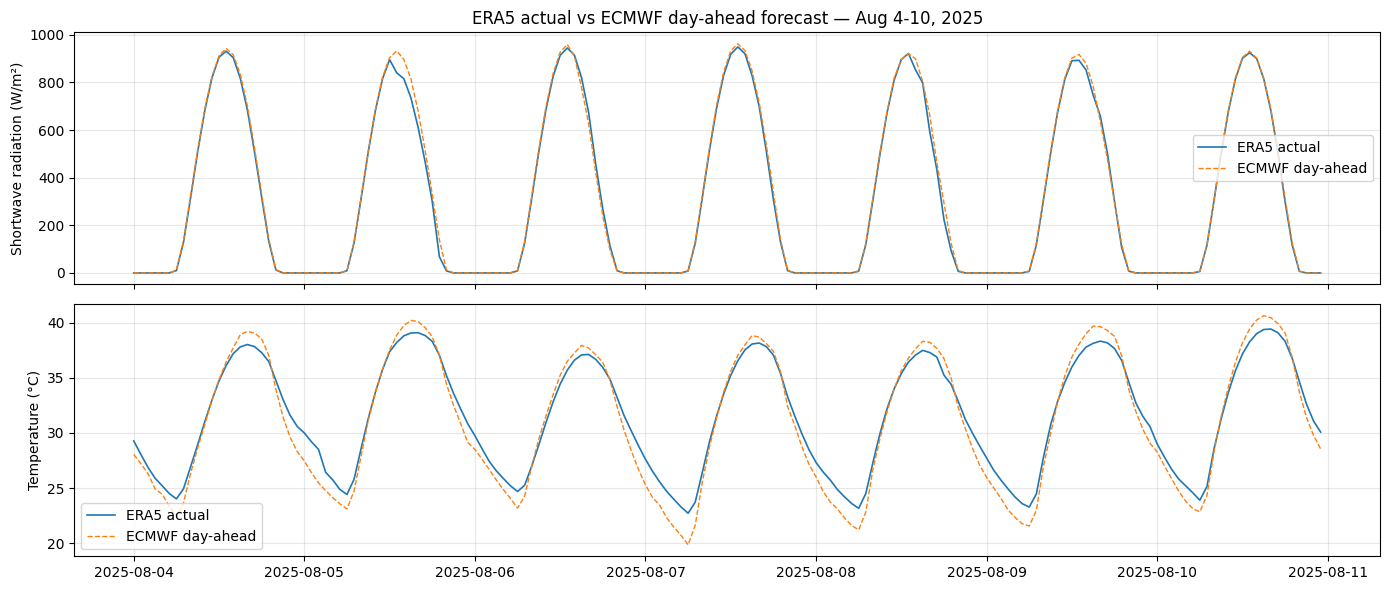

Correlation ERA5 vs forecast  ssrd_wm2                        r = 0.9938
Correlation ERA5 vs forecast  temperature_2m_C                r = 0.9935
Correlation ERA5 vs forecast  total_precip_mm                 r = 0.8071


In [43]:
# ── Spot-check: compare ERA5 vs forecast for a clear summer week ──
import matplotlib.pyplot as plt

sample = dataset.loc['2025-08-04':'2025-08-10']

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(sample.index, sample['ssrd_wm2'],          label='ERA5 actual',       linewidth=1.2)
axes[0].plot(sample.index, sample['ssrd_wm2_forecast'], label='ECMWF day-ahead',   linewidth=1.0, linestyle='--')
axes[0].set_ylabel('Shortwave radiation (W/m²)')
axes[0].set_title('ERA5 actual vs ECMWF day-ahead forecast — Aug 4-10, 2025')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(sample.index, sample['temperature_2m_C'],          label='ERA5 actual',     linewidth=1.2)
axes[1].plot(sample.index, sample['temperature_2m_C_forecast'], label='ECMWF day-ahead', linewidth=1.0, linestyle='--')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between ERA5 and forecast (should be high for good NWP)
for col in ['ssrd_wm2', 'temperature_2m_C', 'total_precip_mm']:
    corr = dataset[col].corr(dataset[f'{col}_forecast'])
    print(f'Correlation ERA5 vs forecast  {col:30s}  r = {corr:.4f}')

## Step 5 — Derived forecast features

Recompute `kt` (clearsky index) and `dewpoint_depression` from the forecast values.
These are the same derivations as in notebook 3 (preprocessing), applied to forecast columns.

In [44]:
# kt_forecast: ratio of forecast irradiance to clear-sky (cloud signal in the forecast)
# Clip to [0, 1.2] same as ERA5 version — values slightly above 1 can occur due to reflections
dataset['kt_forecast'] = np.where(
    dataset['clearsky_ghi'] > 10,
    (dataset['ssrd_wm2_forecast'] / dataset['clearsky_ghi']).clip(0, 1.2),
    0.0,
)

# dewpoint_depression_forecast: how far temperature is above dewpoint (proxy for humidity)
dataset['dewpoint_depression_C_forecast'] = (
    dataset['temperature_2m_C_forecast'] - dataset['dewpoint_2m_C_forecast']
)

print('Derived forecast features added.')
print(f"kt_forecast range:                  [{dataset['kt_forecast'].min():.3f}, {dataset['kt_forecast'].max():.3f}]")
print(f"dewpoint_depression_forecast range: [{dataset['dewpoint_depression_C_forecast'].min():.2f}, {dataset['dewpoint_depression_C_forecast'].max():.2f}]")

Derived forecast features added.
kt_forecast range:                  [0.000, 1.200]
dewpoint_depression_forecast range: [0.00, 37.10]


## Step 6 — Validation & export

In [45]:
# ── Final column summary ──
era5_cols     = ['dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa',
                 'total_precip_mm', 'ssrd_wm2', 'strd_wm2']
forecast_cols_all = [c for c in dataset.columns if '_forecast' in c]
static_cols   = ['solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni',
                 'clearsky_dhi', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

print('=' * 60)
print('FINAL DATASET SUMMARY')
print('=' * 60)
print(f'Shape: {dataset.shape}')
print(f'Date range: {dataset.index[0]} to {dataset.index[-1]}')
print(f'\nERA5 observed columns ({len(era5_cols)}):    {era5_cols}')
print(f'\nForecast columns ({len(forecast_cols_all)}):        {forecast_cols_all}')
print(f'\nStatic/derived columns ({len(static_cols)}): {static_cols}')
print(f'\nTarget: pv_generation_gwh')
print(f'\nMissing values per column:')
missing = dataset.isnull().sum()
print(missing[missing > 0])

FINAL DATASET SUMMARY
Shape: (26304, 23)
Date range: 2023-01-01 00:00:00 to 2025-12-31 23:00:00

ERA5 observed columns (6):    ['dewpoint_2m_C', 'temperature_2m_C', 'surface_pressure_hPa', 'total_precip_mm', 'ssrd_wm2', 'strd_wm2']

Forecast columns (7):        ['ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast', 'surface_pressure_hPa_forecast', 'total_precip_mm_forecast', 'kt_forecast', 'dewpoint_depression_C_forecast']

Static/derived columns (9): ['solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'clearsky_dni', 'clearsky_dhi', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

Target: pv_generation_gwh

Missing values per column:
pv_generation_gwh    5084
dtype: int64


In [46]:
output_path = os.path.join(DATA_DIR, 'caceres_nwp_dataset.csv')
dataset.to_csv(output_path)
print(f'Saved to: {output_path}')
print(f'Shape: {dataset.shape}')
print('\nNext step: run notebook 3b_nwp_preprocessing.ipynb')

Saved to: c:\Users\nicol\Documents\ML-solar-forecast\caceres_analysis\data\caceres_nwp_dataset.csv
Shape: (26304, 23)

Next step: run notebook 3b_nwp_preprocessing.ipynb
